[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ElenaVillano/prope-programacion/blob/main/materiales/m08_visualizacion.ipynb)

# Propedéutico de Programación para el Análisis de datos

**EGobiernoyTP, verano 2026**

## Análisis exploratorio y visualización de datos

## Contexto de la base de datos

- **Fuente:** National Center for Health Statistics (NCHS) + U.S. Census Bureau
- **Qué es:** Encuesta experimental en línea (~20 min) lanzada en abril 2020 por el Census Bureau junto con NCHS y otras agencias federales, para medir en tiempo casi real el impacto de la pandemia de COVID-19 en los hogares estadounidenses.
- La base mide **acceso y necesidad de atención de salud mental** entre adultos en Estados Unidos, a lo largo de distintos periodos de levantamiento.
- No son registros individuales: cada fila contiene una **estimación agregada (porcentaje)** para una población y periodo determinados.

#### Diccionario de datos





| Columna | Descripción |
|---|---|
| Indicator | Indicador medido (ej. "Symptoms of Anxiety Disorder") |
| Group | Categoría de desagregación (National Estimate, By Age, By Sex, By State, By Race/Hispanic ethnicity...) |
| State | Estado o "United States" (nacional) |
| Subgroup | Valor específico dentro del Group (ej. "18-29 years") |
| Phase | Fase de la encuesta (1, 2, 3, 3.1...) |
| Time Period | N° secuencial de la ronda de recolección |
| Time Period Label | Rango de fechas legible (ej. "Aug 19 - Aug 31, 2020") |
| Time Period Start Date | Fecha de inicio del periodo |
| Time Period End Date | Fecha de fin del periodo |
| Value | Estimación (%) |
| LowCI | Límite inferior del IC 95% |
| HighCI | Límite superior del IC 95% |
| Confidence Interval | IC en texto (ej. "19.0 - 19.8") |
| Quartile Range | Rango de cuartil (indicadores de vivienda/gasto) |
| Suppression Flag | Marca de supresión por baja fiabilidad estadística |

- Un renglón:
  
  ```
  Indicator: Took Prescription Medication for Mental Health, Last 4 Weeks
  Group: By Age
  State: United States
  Subgroup: 18 - 29 years
  Phase: 2
  Time Period: 13
  Time Period Label: Aug 19 - Aug 31, 2020
  Value: 18.7
  LowCI: 17.2
  HighCI: 20.3
  ```

- Se interpreta de la siguiente manera: durante ese periodo, se estimó que 18.7% de los adultos estadounidenses de 18 a 29 años habían tomado medicamentos recetados para su salud mental en las últimas cuatro semanas, con un intervalo de confianza de 17.2% a 20.3%.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# Estilo base para todas las gráficas del notebook
# 'whitegrid' agrega líneas horizontales de referencia — ayudan a leer valores
sns.set_theme(style='whitegrid', palette='crest')

# Tamaño por defecto de las figuras (ancho x alto en pulgadas)
plt.rcParams['figure.figsize'] = (10, 5)

# Fuente más grande para que se lea bien en pantalla y en proyector
plt.rcParams['font.size'] = 12

In [69]:
# Para ver 100 filas en el notebook
pd.set_option('display.max_rows', 100)
#Para ver 10 columnas en el notebook
pd.set_option('display.max_columns', 10)

In [70]:
# Carga de datos
df = pd.read_csv('https://raw.githubusercontent.com/ElenaVillano/prope-programacion/refs/heads/main/data/datos.csv')
df.head()

,Indicator,Group,State,Subgroup,Phase,...,LowCI,HighCI,Confidence Interval,Quartile Range,Suppression Flag
0,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Male,2,...,6.5,7.3,6.5 - 7.3,NaN,NaN
1,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Female,2,...,10.4,11.6,10.4 - 11.6,NaN,NaN
2,Needed Counseling or Therapy But Did Not Get I...,By Sex,United States,Female,-1,...,NaN,NaN,NaN,NaN,NaN
3,Took Prescription Medication for Mental Health...,By Age,United States,50 - 59 years,-1,...,NaN,NaN,NaN,NaN,NaN
4,Took Prescription Medication for Mental Health...,By Age,United States,60 - 69 years,-1,...,NaN,NaN,NaN,NaN,NaN


## Limpieza

In [71]:
# Hacemos todas las columnas con minúculas y reemplazamos espacios por _
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['indicator', 'group', 'state', 'subgroup', 'phase', 'time_period',
       'time_period_label', 'time_period_start_date', 'time_period_end_date',
       'value', 'lowci', 'highci', 'confidence_interval', 'quartile_range',
       'suppression_flag'],
      dtype='str')

In [72]:
# Solo nos quedamos con las columnas que analizaremos
df.drop(['time_period_label', 'confidence_interval','time_period',
         'quartile_range','suppression_flag'], inplace=True, axis=1)

In [73]:
# Convertimos las variables de tiempo
df['time_period_start_date'] = pd.to_datetime(df['time_period_start_date'], errors='coerce')
df['time_period_end_date'] = pd.to_datetime(df['time_period_end_date'], errors='coerce')

In [74]:
df.dtypes

indicator                            str
group                                str
state                                str
subgroup                             str
phase                                str
time_period_start_date    datetime64[us]
time_period_end_date      datetime64[us]
value                            float64
lowci                            float64
highci                           float64
dtype: object

## Análisis exploratorio descriptivo

In [75]:
df['indicator'].value_counts()

indicator
Received Counseling or Therapy, Last 4 Weeks                                                          2601
Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks                                         2601
Took Prescription Medication for Mental Health, Last 4 Weeks                                          2601
Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks    2601
Name: count, dtype: int64

In [76]:
# Cambiamos el nombre de las etiquitas para facilidad de lectura
df['indicator'] = df['indicator'].replace({'Received Counseling or Therapy, Last 4 Weeks':
                            'Recibió terapia',
                         'Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks':
                            'Necesitó terapia pero no la obtuvo',
                         'Took Prescription Medication for Mental Health, Last 4 Weeks':
                            'Tomó medicamentos para la salud mental',
                         'Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks':
                            'Tomó medicamentos para la salud mental y/o recibió terapia'
                         })

In [77]:
df['indicator'].value_counts()

indicator
Recibió terapia                                               2601
Necesitó terapia pero no la obtuvo                            2601
Tomó medicamentos para la salud mental                        2601
Tomó medicamentos para la salud mental y/o recibió terapia    2601
Name: count, dtype: int64

In [78]:
# El valor de la media de todos los indicadores combinados.
df[(df['group']!='By State') & (df['group']!='National Estimate')].groupby(["indicator","group", "subgroup"])["value"].mean().head(20)

indicator                           group                                          subgroup                                                             
Necesitó terapia pero no la obtuvo  By Age                                         18 - 29 years                                                            19.848485
                                                                                   30 - 39 years                                                            15.566667
                                                                                   40 - 49 years                                                            11.845455
                                                                                   50 - 59 years                                                             9.148485
                                                                                   60 - 69 years                                                             5.775758
                 

## Análisis visual

#### Histograma

Distribución de frecuencias

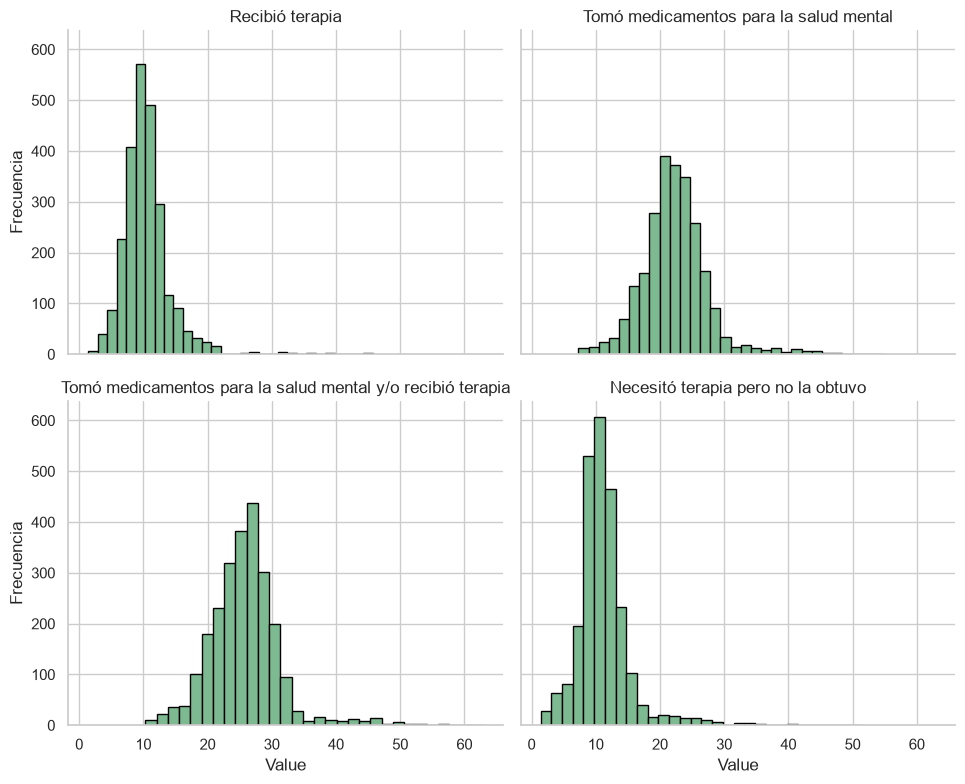

In [89]:
g = sns.FacetGrid(df.dropna(subset=['value', 'indicator']),
                  col='indicator',
                  col_wrap=2,
                  height=4,
                  aspect=1.2,
                  sharex=True, sharey=True)
g.map(plt.hist, 'value', bins=30, edgecolor='k')
g.set_titles("{col_name}")
g.set_axis_labels('Value', 'Frecuencia')
plt.show()

#### Boxplot o diagrama de caja

Un **boxplot** resume la distribución y permite observar la mediana, los cuartiles, la dispersión y posibles valores atípicos.

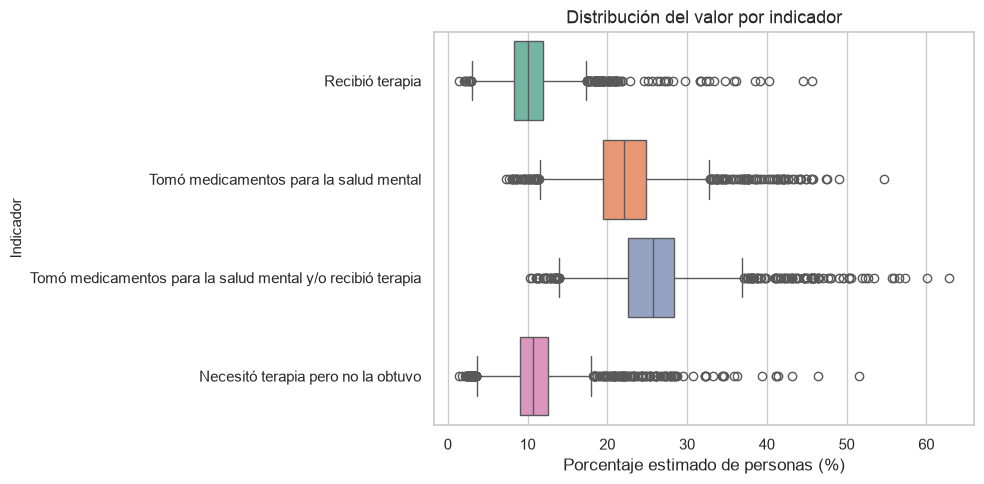

In [107]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df.dropna(subset=['value', 'indicator']),
    y='indicator', # ¿Qué pasa si el bimestre va en el eje y?
    x='value',
    palette='Set2',
    hue='indicator',
    legend=False,  # ¿Qué pasa si le pones True?
    ax=ax
)

ax.set_title('Distribución del valor por indicador', fontsize=13)
ax.set_xlabel('Porcentaje estimado de personas (%)')
ax.set_ylabel('Indicador', fontsize=11)

plt.tight_layout()
plt.show()

#### Scatterplot o gráfico de dispersión

Se usa para la relación entre dos variables numéricas

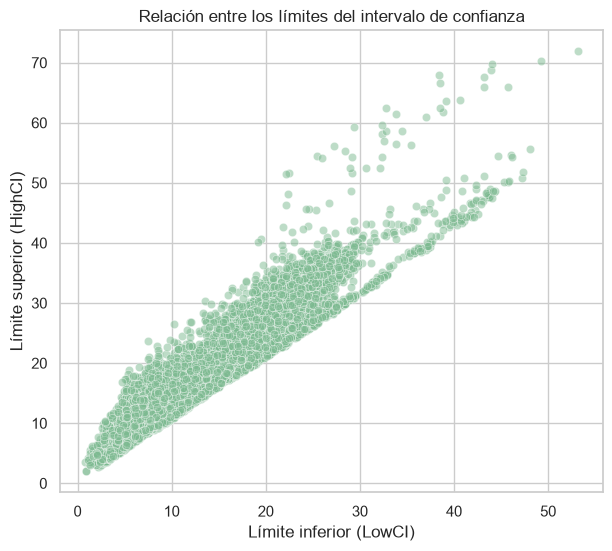

In [108]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=df,
    x='lowci',
    y='highci',
    alpha=0.5
)

plt.xlabel('Límite inferior (LowCI)')
plt.ylabel('Límite superior (HighCI)')
plt.title('Relación entre los límites del intervalo de confianza')

plt.show()

##### Hacerlo solo por el estimado Nacional

In [86]:
df_nacional = df[df['group'] == 'National Estimate']

In [91]:
df_nacional

,indicator,group,state,subgroup,phase,time_period_start_date,time_period_end_date,value,lowci,highci
13,Tomó medicamentos para la salud mental,National Estimate,United States,United States,2,2020-08-19,2020-08-31,19.4,19.0,19.8
85,Recibió terapia,National Estimate,United States,United States,2,2020-08-19,2020-08-31,8.7,8.3,9.2
157,Tomó medicamentos para la salud mental y/o rec...,National Estimate,United States,United States,2,2020-08-19,2020-08-31,22.4,22.0,22.9
229,Necesitó terapia pero no la obtuvo,National Estimate,United States,United States,2,2020-08-19,2020-08-31,9.2,8.8,9.6
301,Tomó medicamentos para la salud mental,National Estimate,United States,United States,2,2020-09-02,2020-09-14,19.6,19.1,20.2
...,...,...,...,...,...,...,...,...,...,...
10004,Necesitó terapia pero no la obtuvo,National Estimate,United States,United States,3.4,2022-03-30,2022-04-11,11.5,11.0,11.9
10084,Tomó medicamentos para la salud mental,National Estimate,United States,United States,3.4,2022-04-27,2022-05-09,23.1,22.3,24.0
10164,Recibió terapia,National Estimate,United States,United States,3.4,2022-04-27,2022-05-09,11.3,10.8,11.9
10244,Tomó medicamentos para la salud mental y/o rec...,National Estimate,United States,United States,3.4,2022-04-27,2022-05-09,26.8,26.0,27.7


##### Histograma

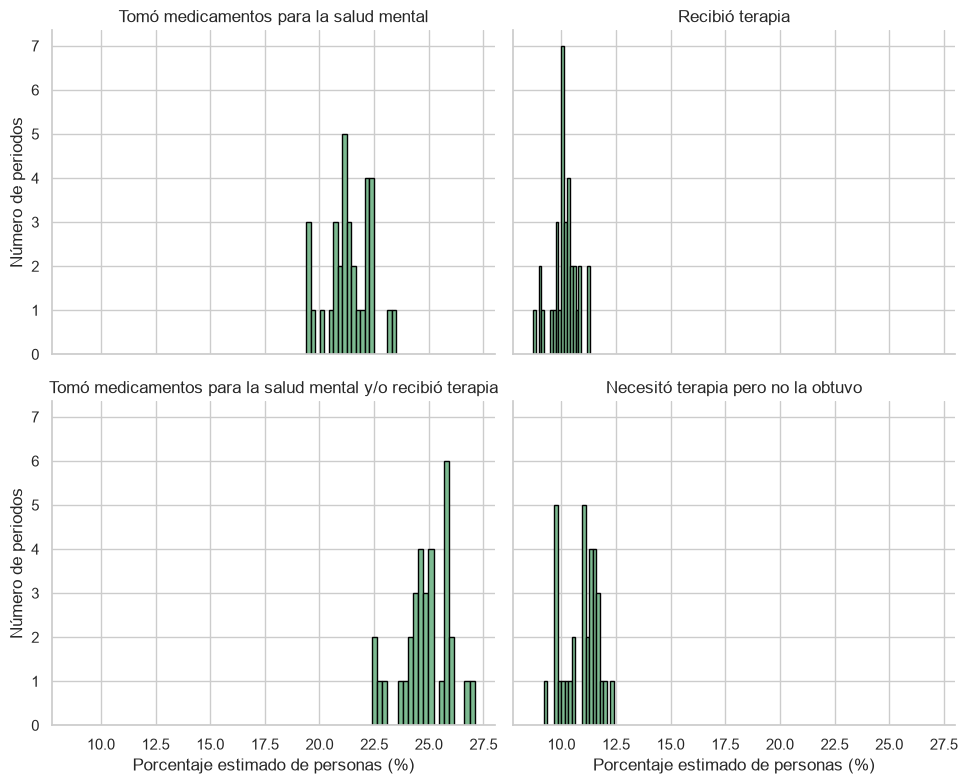

In [93]:
g = sns.FacetGrid(
    df_nacional.dropna(subset=['value', 'indicator']),
    col='indicator',
    col_wrap=2,
    height=4,
    aspect=1.2,
    sharex=True,
    sharey=True
)

g.map(plt.hist, 'value', bins=20, edgecolor='k')

g.set_axis_labels(
    'Porcentaje estimado de personas (%)',
    'Número de periodos'
)
g.set_titles("{col_name}")
plt.show()

##### Histograma

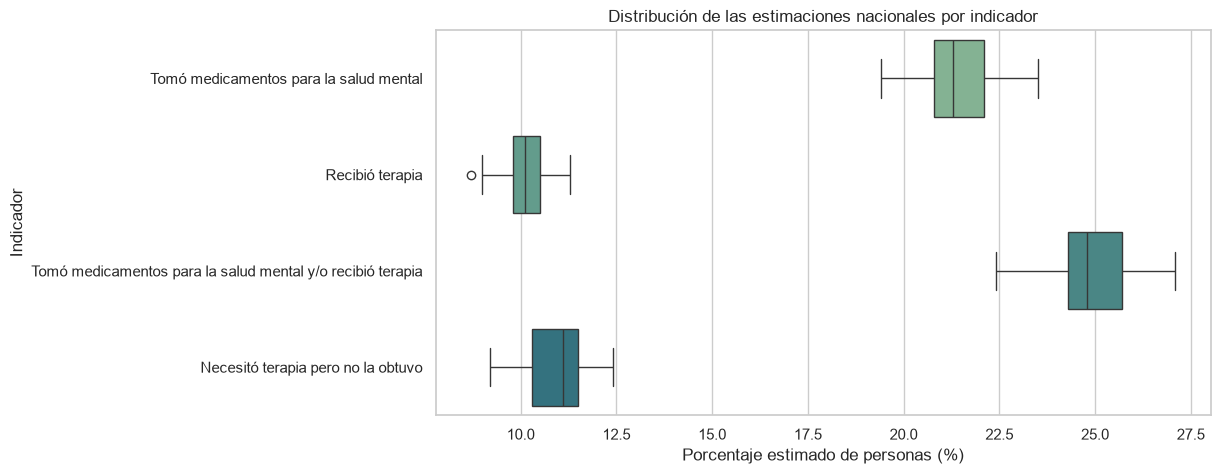

In [82]:
sns.boxplot(
    data=df_nacional.dropna(subset=['value', 'indicator']),
    y='indicator',
    x='value',
    hue='indicator',
    legend=False
)

plt.xlabel('Porcentaje estimado de personas (%)')
plt.ylabel('Indicador')
plt.title('Distribución de las estimaciones nacionales por indicador')

plt.show()

#### Gráfico de barras

Los gráficos de barras permiten comparar cantidades entre categorías.

Primero contamos cuántas observaciones existen para cada `group`.

##### Edad

In [94]:
df_edad = df[df['group']=='By Age']

In [95]:
# Calcular promedio por indicador y grupo de edad
promedio_edad = (
    df_edad
    .groupby(['indicator', 'subgroup'])['value']
    .mean()
      .reset_index()
    .sort_values(['indicator','subgroup','value'], ascending=[True,True,False])

)

promedio_edad

,indicator,subgroup,value
0,Necesitó terapia pero no la obtuvo,18 - 29 years,19.848485
1,Necesitó terapia pero no la obtuvo,30 - 39 years,15.566667
2,Necesitó terapia pero no la obtuvo,40 - 49 years,11.845455
3,Necesitó terapia pero no la obtuvo,50 - 59 years,9.148485
4,Necesitó terapia pero no la obtuvo,60 - 69 years,5.775758
5,Necesitó terapia pero no la obtuvo,70 - 79 years,3.263636
6,Necesitó terapia pero no la obtuvo,80 years and above,3.403846
7,Recibió terapia,18 - 29 years,15.242424
8,Recibió terapia,30 - 39 years,14.463636
9,Recibió terapia,40 - 49 years,11.427273


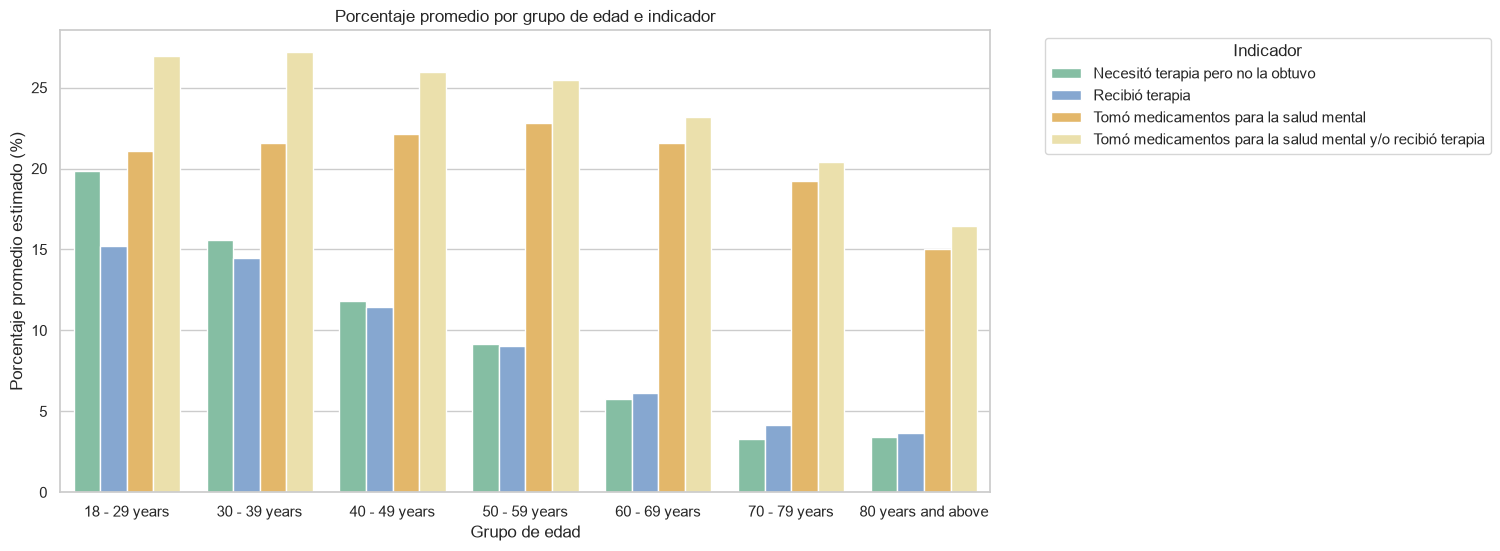

In [98]:
plt.figure(figsize=(12, 6))


colores = [
    '#7BC8A4',  # verde pastel
    '#7AA6DC',  # azul pastel
    '#f7bd56',   # naranja paster
    '#F6E7A1'   # amarillo pastel
]

sns.barplot(
    data=promedio_edad,
    x='subgroup',
    y='value',
    hue='indicator',
    palette=colores
)

plt.xlabel('Grupo de edad')
plt.ylabel('Porcentaje promedio estimado (%)')
plt.title('Porcentaje promedio por grupo de edad e indicador')


plt.legend(
    title='Indicador',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)


plt.show()

##### Nivel Educativo

In [100]:
# Filtrar por nivel educativo
df_educacion = df[df['group'] == 'By Education']

# Calcular promedio
promedio_educacion = (
    df_educacion
    .groupby(['indicator', 'subgroup'])['value']
    .mean()
    .reset_index()
)

promedio_educacion

,indicator,subgroup,value
0,Necesitó terapia pero no la obtuvo,Bachelor's degree or higher,10.609091
1,Necesitó terapia pero no la obtuvo,High school diploma or GED,8.748485
2,Necesitó terapia pero no la obtuvo,Less than a high school diploma,10.545455
3,Necesitó terapia pero no la obtuvo,Some college/Associate's degree,13.472727
4,Recibió terapia,Bachelor's degree or higher,12.596970
5,Recibió terapia,High school diploma or GED,6.921212
6,Recibió terapia,Less than a high school diploma,8.439394
7,Recibió terapia,Some college/Associate's degree,10.903030
8,Tomó medicamentos para la salud mental,Bachelor's degree or higher,20.806061
9,Tomó medicamentos para la salud mental,High school diploma or GED,20.033333


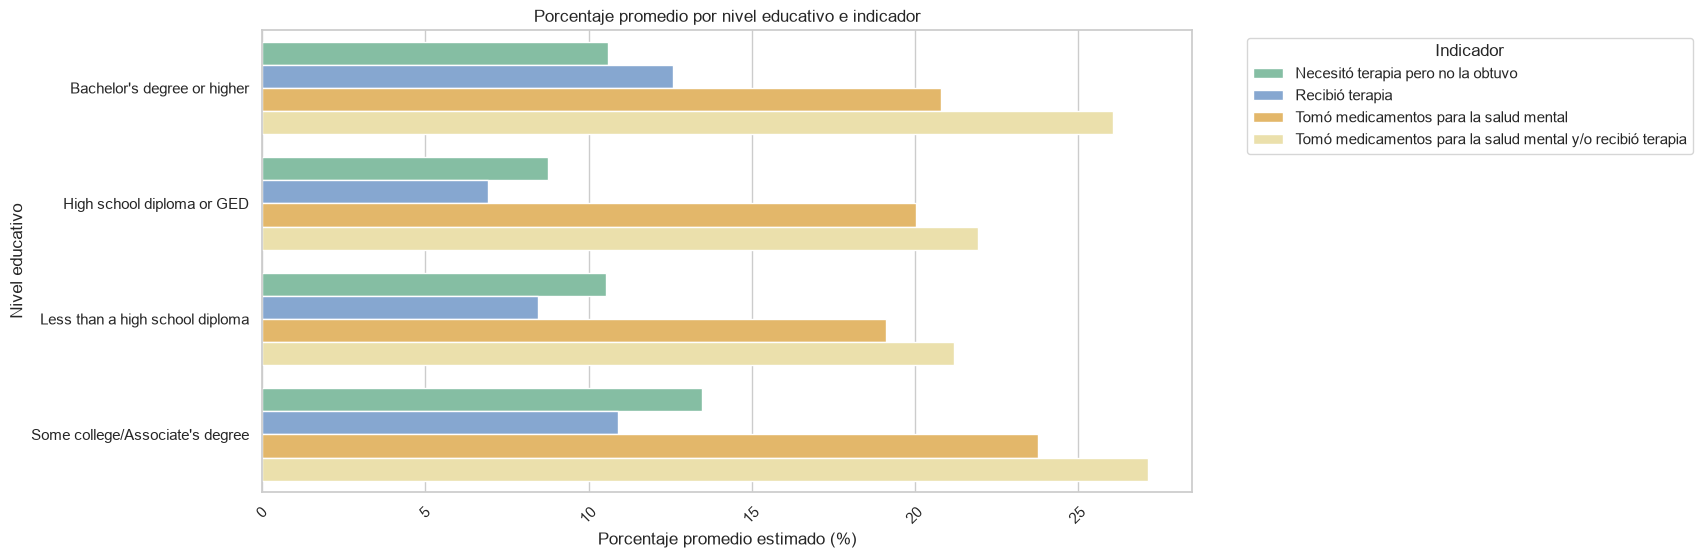

In [101]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=promedio_educacion,
    x='value',
    y='subgroup',
    hue='indicator',
    palette=colores
)

plt.xlabel('Porcentaje promedio estimado (%)')
plt.ylabel('Nivel educativo')
plt.title('Porcentaje promedio por nivel educativo e indicador')

plt.xticks(rotation=45)

plt.legend(
    title='Indicador',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

##### Presencia de síntomas de ansiedad y depresión

In [102]:
# Filtrar por presencia de síntomas de ansiedad/depresión
df_sintomas = df[
    df['group'] == 'By Presence of Symptoms of Anxiety/Depression'
]

# Calcular promedio
promedio_sintomas = (
    df_sintomas
    .groupby(['indicator', 'subgroup'])['value']
    .mean()
    .reset_index()
)

promedio_sintomas

,indicator,subgroup,value
0,Necesitó terapia pero no la obtuvo,Did not experience symptoms of anxiety/depress...,3.418182
1,Necesitó terapia pero no la obtuvo,Experienced symptoms of anxiety/depression in ...,25.287879
2,Recibió terapia,Did not experience symptoms of anxiety/depress...,5.854545
3,Recibió terapia,Experienced symptoms of anxiety/depression in ...,18.312121
4,Tomó medicamentos para la salud mental,Did not experience symptoms of anxiety/depress...,13.727273
5,Tomó medicamentos para la salud mental,Experienced symptoms of anxiety/depression in ...,35.915152
6,Tomó medicamentos para la salud mental y/o rec...,Did not experience symptoms of anxiety/depress...,16.342424
7,Tomó medicamentos para la salud mental y/o rec...,Experienced symptoms of anxiety/depression in ...,40.978788


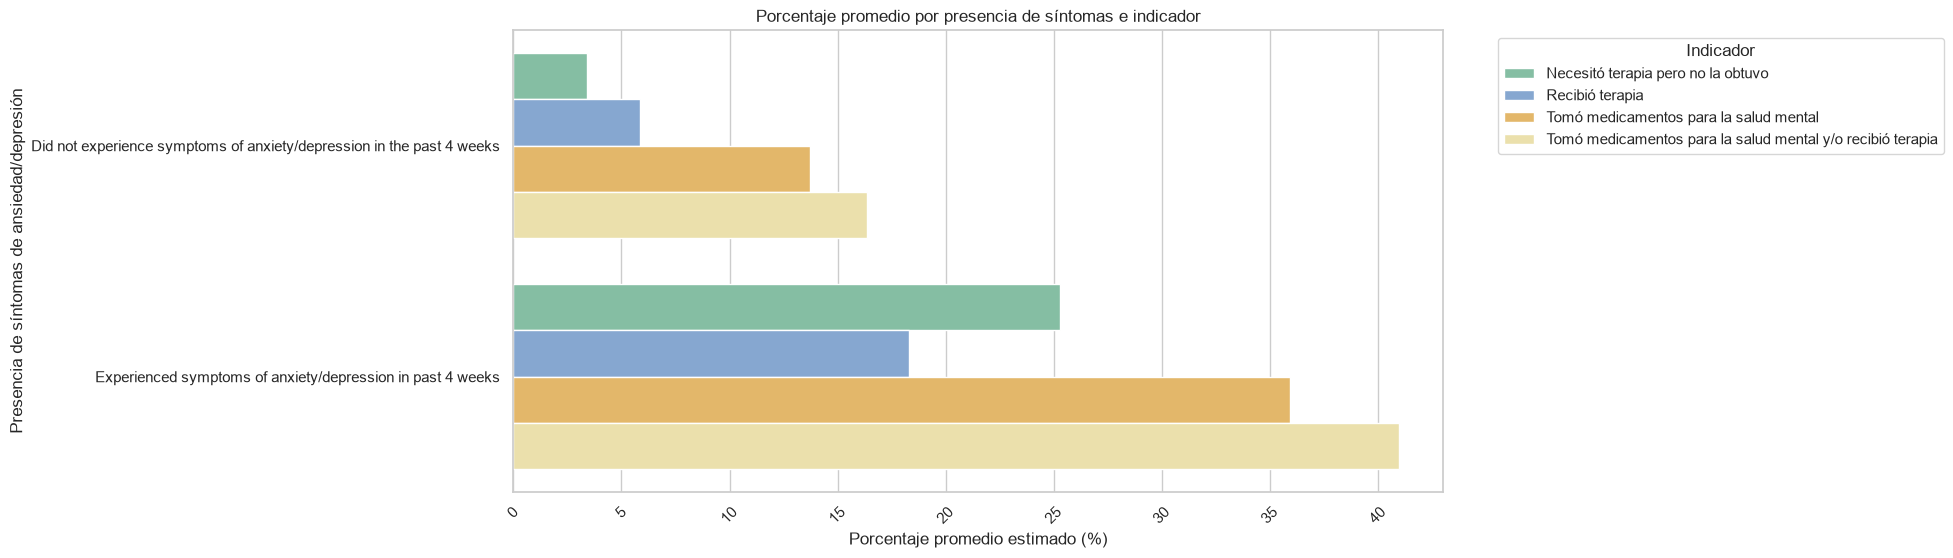

In [103]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=promedio_sintomas,
    x='value',
    y='subgroup',
    hue='indicator',
    palette=colores
)

plt.xlabel('Porcentaje promedio estimado (%)')
plt.ylabel('Presencia de síntomas de ansiedad/depresión')
plt.title('Porcentaje promedio por presencia de síntomas e indicador')

plt.xticks(rotation=45)

plt.legend(
    title='Indicador',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

#### Línea del tiempo

Para construir una línea del tiempo necesitamos asegurarnos que la fecha tenga un tipo de dato adecuado.

In [104]:
df.dtypes

indicator                            str
group                                str
state                                str
subgroup                             str
phase                                str
time_period_start_date    datetime64[us]
time_period_end_date      datetime64[us]
value                            float64
lowci                            float64
highci                           float64
dtype: object

Como existen múltiples observaciones para una misma fecha, primero resumimos la información calculando el promedio de `value` por fecha.

In [105]:
# Calcular el promedio por fecha e indicador
serie_tiempo = (
    df
    .groupby(['time_period_end_date', 'indicator'])['value']
    .mean()
    .reset_index()
)

serie_tiempo

,time_period_end_date,indicator,value
0,2020-08-31,Necesitó terapia pero no la obtuvo,8.977778
1,2020-08-31,Recibió terapia,8.706944
2,2020-08-31,Tomó medicamentos para la salud mental,19.747222
3,2020-08-31,Tomó medicamentos para la salud mental y/o rec...,22.809722
4,2020-09-14,Necesitó terapia pero no la obtuvo,9.630556
...,...,...,...
147,2022-04-11,Tomó medicamentos para la salud mental y/o rec...,28.576250
148,2022-05-09,Necesitó terapia pero no la obtuvo,12.372500
149,2022-05-09,Recibió terapia,12.055000
150,2022-05-09,Tomó medicamentos para la salud mental,24.655000


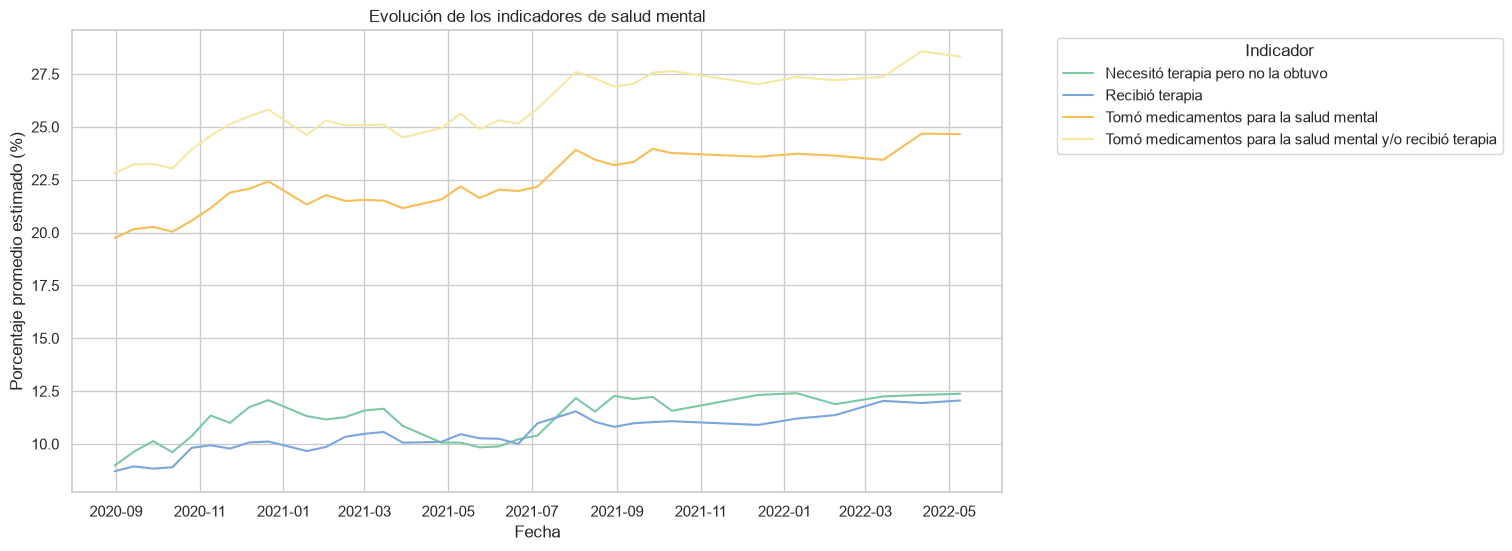

In [109]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=serie_tiempo,
    x='time_period_end_date',
    y='value',
    hue='indicator',
    palette=colores
)

plt.xlabel('Fecha')
plt.ylabel('Porcentaje promedio estimado (%)')
plt.title('Evolución de los indicadores de salud mental')

plt.legend(
    title='Indicador',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

#### Mapa interactivo

In [110]:
# Filtrar información por estado
df_estados = df[df['group'] == 'By State']

promedio_estados = (
    df_estados
    .groupby('state')['value']
    .mean()
    .reset_index()
)

promedio_estados.head()

,state,value
0,Alabama,18.059848
1,Alaska,15.571212
2,Arizona,15.950758
3,Arkansas,18.710606
4,California,15.145455


In [111]:
df['indicator'].unique()

<StringArray>
[                                           'Recibió terapia',
                         'Necesitó terapia pero no la obtuvo',
                     'Tomó medicamentos para la salud mental',
 'Tomó medicamentos para la salud mental y/o recibió terapia']
Length: 4, dtype: str

In [112]:
indicador = 'Necesitó terapia pero no la obtuvo'

In [114]:
df_mapa = df[
    (df['group'] == 'By State') &
    (df['indicator'] == indicador)
]

promedio_estados = (
    df_mapa
    .groupby('state')['value']
    .mean()
    .reset_index()
)

promedio_estados.head()

,state,value
0,Alabama,11.363636
1,Alaska,11.469697
2,Arizona,11.493939
3,Arkansas,11.318182
4,California,11.651515


In [115]:
abreviaturas = {
    'Alabama':'AL', 'Alaska':'AK', 'Arizona':'AZ', 'Arkansas':'AR',
    'California':'CA', 'Colorado':'CO', 'Connecticut':'CT', 'Delaware':'DE',
    'Florida':'FL', 'Georgia':'GA', 'Hawaii':'HI', 'Idaho':'ID',
    'Illinois':'IL', 'Indiana':'IN', 'Iowa':'IA', 'Kansas':'KS',
    'Kentucky':'KY', 'Louisiana':'LA', 'Maine':'ME', 'Maryland':'MD',
    'Massachusetts':'MA', 'Michigan':'MI', 'Minnesota':'MN', 'Mississippi':'MS',
    'Missouri':'MO', 'Montana':'MT', 'Nebraska':'NE', 'Nevada':'NV',
    'New Hampshire':'NH', 'New Jersey':'NJ', 'New Mexico':'NM',
    'New York':'NY', 'North Carolina':'NC', 'North Dakota':'ND',
    'Ohio':'OH', 'Oklahoma':'OK', 'Oregon':'OR', 'Pennsylvania':'PA',
    'Rhode Island':'RI', 'South Carolina':'SC', 'South Dakota':'SD',
    'Tennessee':'TN', 'Texas':'TX', 'Utah':'UT', 'Vermont':'VT',
    'Virginia':'VA', 'Washington':'WA', 'West Virginia':'WV',
    'Wisconsin':'WI', 'Wyoming':'WY'
}

promedio_estados['codigo'] = promedio_estados['state'].map(abreviaturas)

In [118]:
fig = px.choropleth(
    promedio_estados,
    locations='codigo',
    locationmode='USA-states',
    color='value',
    scope='usa',
    hover_name='state',
    hover_data={'value': ':.1f', 'codigo': False},
    labels={'value': 'Porcentaje (%)'},
    title='Uso de medicamentos para salud mental por estado'
)

fig.show()